# DeepLense Test 5 - Lens vs Non-Lens Classification

Binary classifier for lens detection with severe class imbalance.

In [1]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

plt.style.use('seaborn-v0_8-whitegrid')

# Config
SEED = 42
VAL_SIZE = 0.1
BATCH_SIZE = 256
EPOCHS = 80
LR = 3e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 5
TARGET_MAX_FPR = 0.005  # Deployment-level false positive budget
REPORT_PREVALENCES = [0.001, 0.005, 0.01, 0.02, 0.05]
NUM_WORKERS = 4

# Paths
cwd = Path.cwd()
ROOT = cwd if (cwd / 'dataset').exists() else cwd / 'test5'
DATA_ROOT = ROOT / 'dataset'
ARTIFACTS = ROOT / 'artifacts'
ARTIFACTS.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Non-lens', 'Lens']

# Seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pin_memory = device.type == 'cuda'

print(f'Device: {device}')
print(f'Data: {DATA_ROOT}')

Device: cuda
Data: /home/colin/gsoc26-deeplense/test5/dataset


In [2]:
# Load data
def load_class(folder_name, label):
    paths = sorted((DATA_ROOT / folder_name).glob('*.npy'))
    if not paths:
        raise FileNotFoundError(f'No .npy files in {DATA_ROOT / folder_name}')
    return [(str(p), label) for p in paths]

train_data = load_class('train_nonlenses', 0) + load_class('train_lenses', 1)
test_data = load_class('test_nonlenses', 0) + load_class('test_lenses', 1)

train_paths, train_labels = zip(*train_data)
test_paths, test_labels = zip(*test_data)

# Split train into train/val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    list(train_paths), list(train_labels), 
    test_size=VAL_SIZE, stratify=train_labels, random_state=SEED
)

# Class distribution
train_pos = sum(train_labels)
val_pos = sum(val_labels)
test_pos = sum(test_labels)

print(f'Train: {len(train_labels)} ({train_pos} lens, {len(train_labels)-train_pos} non-lens)')
print(f'Val: {len(val_labels)} ({val_pos} lens, {len(val_labels)-val_pos} non-lens)')
print(f'Test: {len(test_labels)} ({test_pos} lens, {len(test_labels)-test_pos} non-lens)')
print(f'\\nPositive class fraction: train={train_pos/len(train_labels):.4f}, val={val_pos/len(val_labels):.4f}, test={test_pos/len(test_labels):.4f}')

Train: 27364 (1557 lens, 25807 non-lens)
Val: 3041 (173 lens, 2868 non-lens)
Test: 19650 (195 lens, 19455 non-lens)
\nPositive class fraction: train=0.0569, val=0.0569, test=0.0099


In [3]:
# Compute normalization stats (RGB channels)
channel_sum = np.zeros(3)
channel_sq = np.zeros(3)
total_pixels = 0

for path in train_paths:
    img = np.load(path).astype(np.float32)  # Shape: (3, 64, 64)
    channel_sum += img.reshape(3, -1).sum(axis=1)
    channel_sq += (img.reshape(3, -1) ** 2).sum(axis=1)
    total_pixels += img.shape[1] * img.shape[2]

mean = channel_sum / total_pixels
std = np.sqrt(channel_sq / total_pixels - mean ** 2)

print(f'Mean (RGB): {mean}')
print(f'Std (RGB): {std}')

Mean (RGB): [0.27479378 0.19204788 0.10544324]
Std (RGB): [0.17389129 0.15521556 0.11303987]


In [4]:
# Dataset and DataLoaders
class LensDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, i):
        img = torch.from_numpy(np.load(self.paths[i]).astype(np.float32))
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[i], dtype=torch.float32)

# Transforms
class RandomRotate90:
    """Rotate by multiples of 90 degrees without interpolation blur."""

    def __call__(self, img):
        k = torch.randint(0, 4, ()).item()
        return torch.rot90(img, k, dims=(-2, -1))

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    RandomRotate90(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

eval_transform = transforms.Normalize(mean.tolist(), std.tolist())

# DataLoaders
train_loader = DataLoader(
    LensDataset(train_paths, train_labels, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory
)
val_loader = DataLoader(
    LensDataset(val_paths, val_labels, eval_transform),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=pin_memory
)
test_loader = DataLoader(
    LensDataset(test_paths, test_labels, eval_transform),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=pin_memory
)

In [5]:
# Model
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm2d(out_ch))
            if stride != 1 or in_ch != out_ch else nn.Identity()
        )
    
    def forward(self, x):
        out = torch.nn.functional.silu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return torch.nn.functional.silu(out + self.shortcut(x))

class LensBinaryResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU()
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32))
        self.layer2 = nn.Sequential(ResidualBlock(32, 64, 2), ResidualBlock(64, 64))
        self.layer3 = nn.Sequential(ResidualBlock(64, 128, 2), ResidualBlock(128, 128))
        self.layer4 = nn.Sequential(ResidualBlock(128, 256, 2), ResidualBlock(256, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, 1))
    
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)

model = LensBinaryResNet().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 2,795,297


In [6]:
# Training with class imbalance handling
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=pin_memory)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits)
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    y_true = torch.cat(all_labels).numpy()
    y_prob = torch.cat(all_probs).numpy()

    return {
        'auroc': roc_auc_score(y_true, y_prob),
        'ap': average_precision_score(y_true, y_prob),
        'low_fpr_pauc': roc_auc_score(y_true, y_prob, max_fpr=TARGET_MAX_FPR),
        'labels': y_true,
        'probs': y_prob,
    }


def operating_metrics(labels, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    fpr = fp / (fp + tn) if fp + tn else 0.0
    return {
        'preds': preds,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'fpr': float(fpr),
        'positive_rate': float(np.mean(labels)),
        'predicted_positive_rate': float(np.mean(preds)),
    }


def select_threshold_at_max_fpr(labels, probs, max_fpr=TARGET_MAX_FPR):
    fpr_vals, tpr_vals, thresholds = roc_curve(labels, probs)
    valid_idx = np.where(fpr_vals <= max_fpr)[0]
    if len(valid_idx) == 0:
        threshold = 1.0
    else:
        best_idx = min(
            valid_idx,
            key=lambda i: (-tpr_vals[i], fpr_vals[i], -thresholds[i]),
        )
        threshold = float(thresholds[best_idx])

    metrics = operating_metrics(labels, probs, threshold)
    metrics['threshold'] = float(threshold)
    return metrics


def expected_precision_at_prevalence(recall, fpr, prevalence):
    denom = recall * prevalence + fpr * (1.0 - prevalence)
    if denom == 0:
        return float('nan')
    return float((recall * prevalence) / denom)


def prevalence_table(metrics, prevalences=REPORT_PREVALENCES):
    rows = []
    for prevalence in prevalences:
        rows.append({
            'prevalence_pct': prevalence * 100.0,
            'expected_precision': expected_precision_at_prevalence(
                metrics['recall'],
                metrics['fpr'],
                prevalence,
            ),
        })
    return pd.DataFrame(rows)


# Compute pos_weight for class imbalance
neg_count = len(train_labels) - sum(train_labels)
pos_count = sum(train_labels)
pos_weight = torch.tensor([neg_count / pos_count]).to(device)
print(f'Positive class weight: {pos_weight.item():.2f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_score = (-np.inf, -np.inf, -np.inf)
best_state = copy.deepcopy(model.state_dict())
best_summary = None
patience = 0
history = []

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_loss = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)

        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(imgs)

    # Validate
    val_results = evaluate(model, val_loader)
    val_operating = select_threshold_at_max_fpr(val_results['labels'], val_results['probs'])
    scheduler.step(val_results['low_fpr_pauc'])
    lr = optimizer.param_groups[0]['lr']

    history.append({
        'epoch': epoch,
        'train_loss': train_loss / len(train_loader.dataset),
        'val_auroc': val_results['auroc'],
        'val_ap': val_results['ap'],
        'val_low_fpr_pauc': val_results['low_fpr_pauc'],
        'val_recall_at_target_fpr': val_operating['recall'],
        'val_fpr_at_selected_threshold': val_operating['fpr'],
        'val_threshold': val_operating['threshold'],
        'lr': lr,
    })

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss / len(train_loader.dataset):.4f} | "
        f"val_pAUC@FPR<={TARGET_MAX_FPR:.3f}={val_results['low_fpr_pauc']:.4f} "
        f"val_recall={val_operating['recall']:.4f} val_fpr={val_operating['fpr']:.4f} | "
        f"lr={lr:.2e}"
    )

    current_score = (
        float(val_results['low_fpr_pauc']),
        float(val_operating['recall']),
        float(-val_operating['fpr']),
    )
    if current_score > best_score:
        best_score = current_score
        best_state = copy.deepcopy(model.state_dict())
        best_summary = {
            'low_fpr_pauc': float(val_results['low_fpr_pauc']),
            'recall_at_target_fpr': float(val_operating['recall']),
            'fpr_at_selected_threshold': float(val_operating['fpr']),
            'threshold': float(val_operating['threshold']),
        }
        torch.save(
            {'model': best_state, 'history': history, 'best_summary': best_summary},
            ARTIFACTS / 'best_model.pt',
        )
        patience = 0
    else:
        patience += 1
        if patience >= EARLY_STOP_PATIENCE:
            print('Early stopping')
            break

model.load_state_dict(best_state)
print(f"Best val low-FPR pAUC: {best_summary['low_fpr_pauc']:.4f}")
print(
    f"Best val operating point: threshold={best_summary['threshold']:.6f} "
    f"recall={best_summary['recall_at_target_fpr']:.4f} "
    f"fpr={best_summary['fpr_at_selected_threshold']:.4f}"
)


Positive class weight: 16.57
Epoch 01 | train_loss=0.7890 | val_pAUC@FPR<=0.005=0.5259 val_recall=0.1098 val_fpr=0.0049 | lr=3.00e-04
Epoch 02 | train_loss=0.5148 | val_pAUC@FPR<=0.005=0.5275 val_recall=0.1098 val_fpr=0.0049 | lr=3.00e-04
Epoch 03 | train_loss=0.4465 | val_pAUC@FPR<=0.005=0.5768 val_recall=0.2428 val_fpr=0.0049 | lr=3.00e-04
Epoch 04 | train_loss=0.4271 | val_pAUC@FPR<=0.005=0.5545 val_recall=0.2717 val_fpr=0.0049 | lr=3.00e-04
Epoch 05 | train_loss=0.4020 | val_pAUC@FPR<=0.005=0.5750 val_recall=0.3468 val_fpr=0.0049 | lr=3.00e-04
Epoch 06 | train_loss=0.3580 | val_pAUC@FPR<=0.005=0.5794 val_recall=0.3121 val_fpr=0.0049 | lr=3.00e-04
Epoch 07 | train_loss=0.3530 | val_pAUC@FPR<=0.005=0.5804 val_recall=0.2543 val_fpr=0.0042 | lr=3.00e-04
Epoch 08 | train_loss=0.3165 | val_pAUC@FPR<=0.005=0.6244 val_recall=0.3757 val_fpr=0.0045 | lr=3.00e-04
Epoch 09 | train_loss=0.3351 | val_pAUC@FPR<=0.005=0.6684 val_recall=0.5029 val_fpr=0.0049 | lr=3.00e-04
Epoch 10 | train_loss=0.31

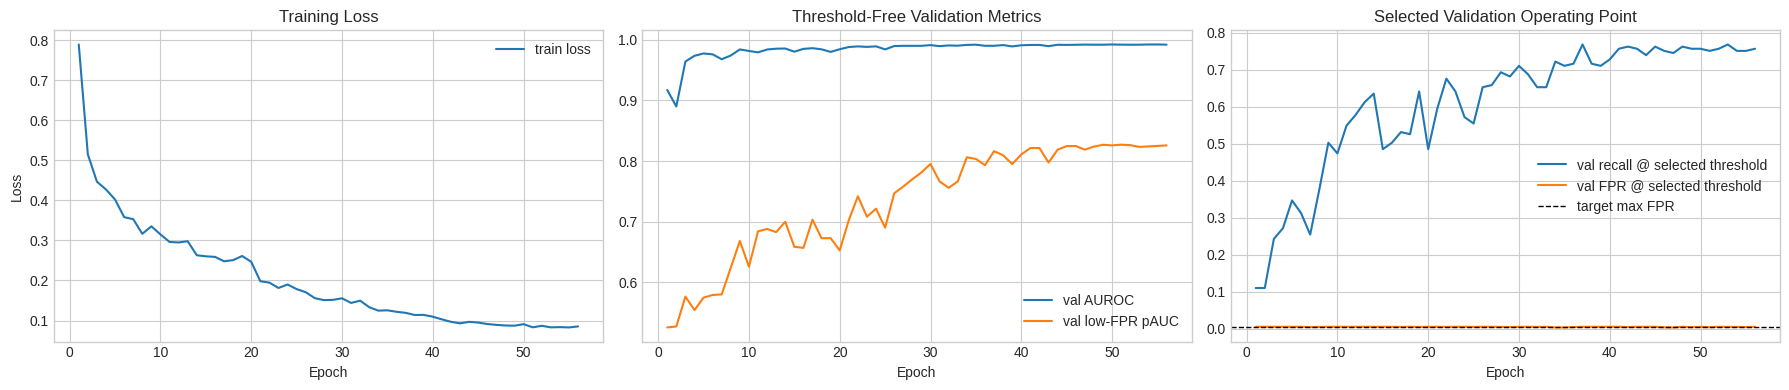

In [7]:
# Plot training curves
df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(df['epoch'], df['train_loss'], label='train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

axes[1].plot(df['epoch'], df['val_auroc'], label='val AUROC')
axes[1].plot(df['epoch'], df['val_low_fpr_pauc'], label='val low-FPR pAUC')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Threshold-Free Validation Metrics')
axes[1].legend()

axes[2].plot(df['epoch'], df['val_recall_at_target_fpr'], label='val recall @ selected threshold')
axes[2].plot(df['epoch'], df['val_fpr_at_selected_threshold'], label='val FPR @ selected threshold')
axes[2].axhline(TARGET_MAX_FPR, color='k', linestyle='--', linewidth=1, label='target max FPR')
axes[2].set_xlabel('Epoch')
axes[2].set_title('Selected Validation Operating Point')
axes[2].legend()

plt.tight_layout()
plt.show()


In [8]:
# Threshold selection and evaluation
val_results = evaluate(model, val_loader)
test_results = evaluate(model, test_loader)

val_operating = select_threshold_at_max_fpr(val_results['labels'], val_results['probs'])
threshold = val_operating['threshold']
test_operating = operating_metrics(test_results['labels'], test_results['probs'], threshold)
test_operating['threshold'] = float(threshold)


def print_split_report(name, results, metrics):
    summary = pd.DataFrame([
        {
            'threshold': metrics['threshold'],
            'tn': metrics['tn'],
            'fp': metrics['fp'],
            'fn': metrics['fn'],
            'tp': metrics['tp'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'fpr': metrics['fpr'],
            'specificity': metrics['specificity'],
            'positive_rate': metrics['positive_rate'],
            'predicted_positive_rate': metrics['predicted_positive_rate'],
        }
    ])

    print(f'\n{name} Results:')
    print(f'  AUROC: {results["auroc"]:.4f}')
    print(f'  AP: {results["ap"]:.4f}')
    print(f'  low-FPR pAUC (max_fpr={TARGET_MAX_FPR:.3f}): {results["low_fpr_pauc"]:.4f}')
    print(summary.round(4).to_string(index=False))
    print(classification_report(results['labels'], metrics['preds'], target_names=CLASS_NAMES, digits=4))
    print('  Expected precision under different prevalence assumptions:')
    print(prevalence_table(metrics).round(4).to_string(index=False))


print(
    f'Selected validation threshold at FPR <= {TARGET_MAX_FPR:.3f}: '
    f'{threshold:.6f}'
)
print_split_report('Validation', val_results, val_operating)
print_split_report('Test', test_results, test_operating)


Selected validation threshold at FPR <= 0.005: 0.971102

Validation Results:
  AUROC: 0.9920
  AP: 0.9160
  low-FPR pAUC (max_fpr=0.005): 0.8271
 threshold   tn  fp  fn  tp  precision  recall    fpr  specificity  positive_rate  predicted_positive_rate
    0.9711 2857  11  43 130      0.922  0.7514 0.0038       0.9962         0.0569                   0.0464
              precision    recall  f1-score   support

    Non-lens     0.9852    0.9962    0.9906      2868
        Lens     0.9220    0.7514    0.8280       173

    accuracy                         0.9822      3041
   macro avg     0.9536    0.8738    0.9093      3041
weighted avg     0.9816    0.9822    0.9814      3041

  Expected precision under different prevalence assumptions:
 prevalence_pct  expected_precision
            0.1              0.1640
            0.5              0.4961
            1.0              0.6643
            2.0              0.7999
            5.0              0.9116

Test Results:
  AUROC: 0.9827
  AP: 

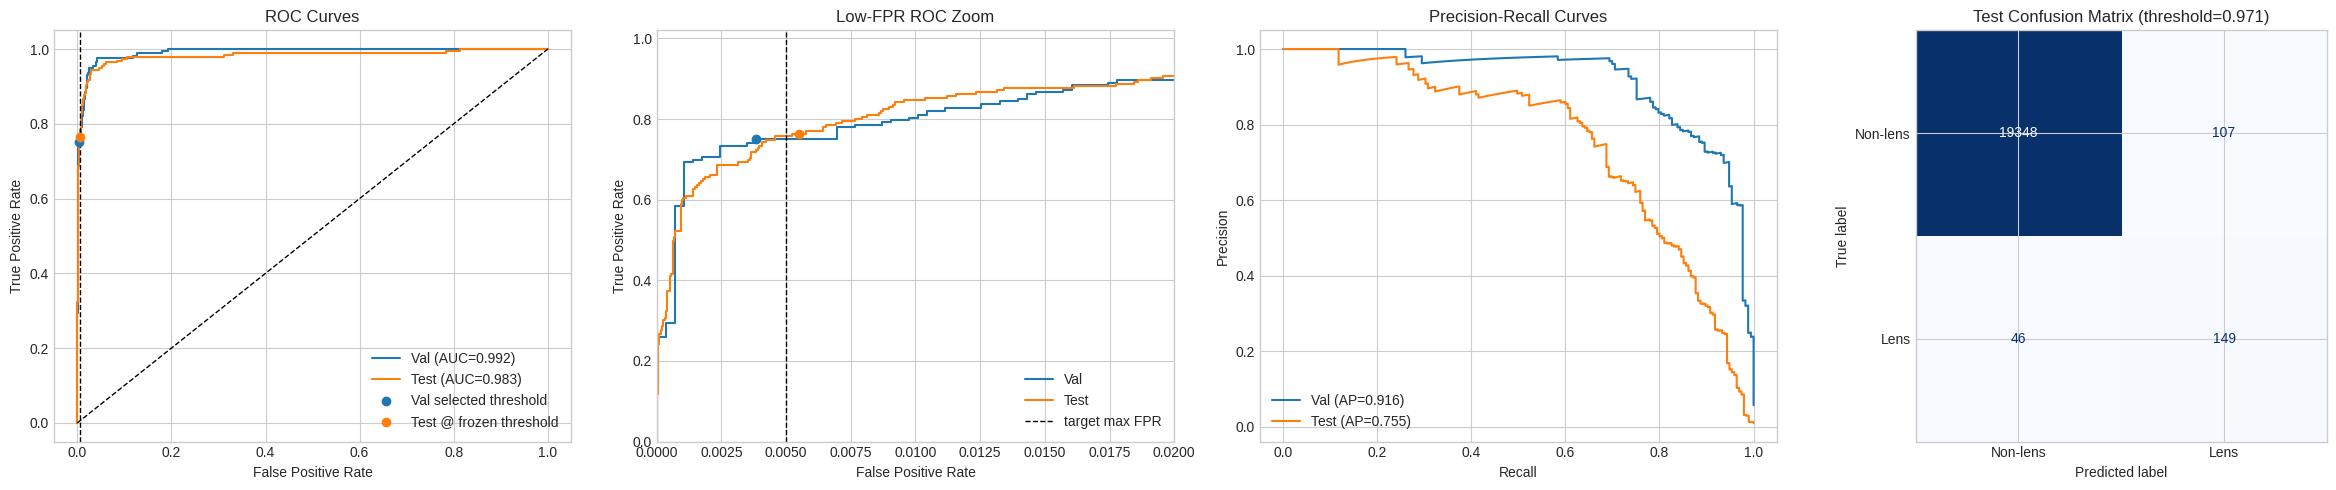

In [9]:
# ROC and PR curves
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# ROC curves
val_fpr, val_tpr, _ = roc_curve(val_results['labels'], val_results['probs'])
test_fpr, test_tpr, _ = roc_curve(test_results['labels'], test_results['probs'])
axes[0].plot(val_fpr, val_tpr, label=f'Val (AUC={val_results["auroc"]:.3f})')
axes[0].plot(test_fpr, test_tpr, label=f'Test (AUC={test_results["auroc"]:.3f})')
axes[0].scatter(val_operating['fpr'], val_operating['recall'], color='tab:blue', zorder=5, label='Val selected threshold')
axes[0].scatter(test_operating['fpr'], test_operating['recall'], color='tab:orange', zorder=5, label='Test @ frozen threshold')
axes[0].axvline(TARGET_MAX_FPR, color='k', linestyle='--', linewidth=1)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# Low-FPR zoom
zoom_xlim = min(0.05, max(0.01, TARGET_MAX_FPR * 4, val_operating['fpr'] * 1.2, test_operating['fpr'] * 1.2))
axes[1].plot(val_fpr, val_tpr, label='Val')
axes[1].plot(test_fpr, test_tpr, label='Test')
axes[1].scatter(val_operating['fpr'], val_operating['recall'], color='tab:blue', zorder=5)
axes[1].scatter(test_operating['fpr'], test_operating['recall'], color='tab:orange', zorder=5)
axes[1].axvline(TARGET_MAX_FPR, color='k', linestyle='--', linewidth=1, label='target max FPR')
axes[1].set_xlim(0, zoom_xlim)
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Low-FPR ROC Zoom')
axes[1].legend()

# PR curves
val_prec, val_rec, _ = precision_recall_curve(val_results['labels'], val_results['probs'])
test_prec, test_rec, _ = precision_recall_curve(test_results['labels'], test_results['probs'])
axes[2].plot(val_rec, val_prec, label=f'Val (AP={val_results["ap"]:.3f})')
axes[2].plot(test_rec, test_prec, label=f'Test (AP={test_results["ap"]:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curves')
axes[2].legend()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    test_results['labels'],
    test_operating['preds'],
    display_labels=CLASS_NAMES,
    cmap='Blues',
    ax=axes[3],
    colorbar=False,
)
axes[3].set_title(f'Test Confusion Matrix (threshold={threshold:.3f})')

plt.tight_layout()
plt.show()
